# Sensor timeline graphs (dual-axis progressive RMSE)

Reads the four Excel files in `data/` and plots **timeline graphs** matching the reference style:

- **X-axis:** time (`Timeline Horizon (hh:mm:ss)`)
- **Left Y-axis:** sensor + reference meter (per chat labels)
- **Right Y-axis:** progressive cumulative RMSE + overall steady-state RMSE

Run all cells (or **Shift+Enter** step by step). Figures are shown inline and saved under `figures/`.

In [5]:
%matplotlib inline

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

DATA_DIR = Path('data')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': ':',
})

print('Data folder:', DATA_DIR.resolve())
print('Figures folder:', FIG_DIR.resolve())

Data folder: D:\StartUps\BitnBolt\hydroponics ML\new start 2\data
Figures folder: D:\StartUps\BitnBolt\hydroponics ML\new start 2\figures


In [6]:
def find_excel(glob_pattern: str) -> Path:
    matches = sorted(DATA_DIR.glob(glob_pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching {glob_pattern!r} in {DATA_DIR.resolve()}')
    return matches[0]


def parse_timeline(series: pd.Series) -> pd.Series:
    """Parse Excel time column to datetime on a fixed date (for plotting only)."""
    base = pd.Timestamp('2000-01-01')
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dt.floor('s')
    parsed = pd.to_datetime(series.astype(str).str.strip(), errors='coerce')
    if parsed.notna().mean() > 0.9:
        return parsed
    return pd.to_datetime(base.strftime('%Y-%m-%d ') + series.astype(str).str.strip(), errors='coerce')


def progressive_rmse(sensor: np.ndarray, reference: np.ndarray) -> np.ndarray:
    err = sensor - reference
    n = len(err)
    return np.sqrt(np.cumsum(err ** 2) / np.arange(1, n + 1))


def load_timeline_dataset(path: Path, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(how='all').copy()
    cols = [str(c).strip() for c in df.columns]
    df.columns = cols

    time_col = next(c for c in cols if 'time' in c.lower())
    value_cols = [c for c in cols if c != time_col]
    if len(value_cols) < 2:
        raise ValueError(f'Expected sensor + meter columns in {path.name}, got {cols}')

    sensor_col, meter_col = value_cols[0], value_cols[1]
    out = pd.DataFrame({
        'time': parse_timeline(df[time_col]),
        'sensor': pd.to_numeric(df[sensor_col], errors='coerce'),
        'meter': pd.to_numeric(df[meter_col], errors='coerce'),
    }).dropna().reset_index(drop=True)
    return out


PLOT_CONFIGS = [
    dict(
        key='tds',
        glob='*TDS*.xlsx',
        title='NFADS TDS Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='TDS (PPM)',
        rmse_unit='PPM',
        sensor_legend='TDS Sensor Stream',
        meter_legend='TDS Meter Baseline (True)',
        outfile='timeline_tds.png',
    ),
    dict(
        key='water_temp',
        glob='*Water*Temp*.xlsx',
        title='NFADS Nutrient Temperature Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Nutrient Temperature (°C)',
        rmse_unit='°C',
        sensor_legend='Nutrient Temperature Sensor Stream',
        meter_legend='Temperature Meter Baseline (True)',
        outfile='timeline_water_temp.png',
    ),
    dict(
        key='ems_temp',
        glob='EMS*.xlsx',
        title='Unified EMS Climate Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Air Temperature (°C)',
        rmse_unit='°C',
        sensor_legend='Environment Temp Sensor Stream',
        meter_legend='Temperature Meter Baseline (True)',
        outfile='timeline_ems_temp.png',
    ),
    dict(
        key='lux',
        glob='LMS*.xlsx',
        title='LMS Light Intensity Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Light Intensity (Lux)',
        rmse_unit='Lux',
        sensor_legend='BH1750 Sensor Stream',
        meter_legend='TSL2591 Meter Baseline (True)',
        outfile='timeline_lux.png',
    ),
]

datasets = {}
for cfg in PLOT_CONFIGS:
    path = find_excel(cfg['glob'])
    df = load_timeline_dataset(path)
    datasets[cfg['key']] = df
    print(f"{cfg['key']:12} | {path.name:28} | n = {len(df):4} | {df['time'].iloc[0]} -> {df['time'].iloc[-1]}")

tds          | Dosing_TDS.xlsx              | n =   42 | 2026-06-02 13:10:45 -> 2026-06-02 13:17:35
water_temp   | Dosing_Water Temp (1).xlsx   | n =  142 | 2026-06-02 13:30:35 -> 2026-06-02 13:54:05
ems_temp     | EMS_temp_sensor (1).xlsx     | n =   36 | 2026-06-02 16:10:35 -> 2026-06-02 16:16:25
lux          | LMS_Lux (1).xlsx             | n =  753 | 2026-06-02 08:50:10 -> 2026-06-02 17:11:30


In [7]:
def plot_dual_axis_timeline(df: pd.DataFrame, cfg: dict, save: bool = True):
    """Reference-style dual-axis timeline: sensor, meter, progressive RMSE, steady-state RMSE."""
    t = df['time']
    sensor = df['sensor'].to_numpy()
    meter = df['meter'].to_numpy()
    prog_rmse = progressive_rmse(sensor, meter)
    steady_rmse = float(np.sqrt(np.mean((sensor - meter) ** 2)))

    fig, ax1 = plt.subplots(figsize=(13.5, 5.8))
    ax2 = ax1.twinx()

    ax1.plot(
        t, sensor,
        color='#E67E22', linewidth=1.6, marker='o', markersize=4,
        label=cfg['sensor_legend'],
    )
    ax1.plot(
        t, meter,
        color='#2471A3', linewidth=1.6, linestyle='--', marker='s', markersize=4,
        label=cfg['meter_legend'],
    )
    ax2.plot(
        t, prog_rmse,
        color='#7D3C98', linewidth=1.6, marker='v', markersize=4,
        label='Progressive Cumulative RMSE',
    )
    ax2.axhline(
        steady_rmse, color='#1E8449', linestyle=':', linewidth=2.0,
        label=f'Overall Steady-State RMSE ({steady_rmse:.4f} {cfg["rmse_unit"]})',
    )

    ax1.set_title(cfg['title'], fontsize=12, fontweight='bold', pad=12)
    ax1.set_xlabel('Timeline Horizon (hh:mm:ss)', fontsize=10)
    ax1.set_ylabel(cfg['y_label'], fontsize=10)
    ax2.set_ylabel(f'Root Mean Square Error ({cfg["rmse_unit"]})', fontsize=10, color='#7D3C98')
    ax2.tick_params(axis='y', labelcolor='#7D3C98')
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=8))

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate(rotation=0, ha='center')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2, labels1 + labels2,
        loc='upper center', bbox_to_anchor=(0.5, -0.14),
        ncol=2, frameon=True, fancybox=True, shadow=True, fontsize=9,
    )

    for ax in (ax1, ax2):
        ax.set_axisbelow(True)
    fig.tight_layout()

    if save:
        out_path = FIG_DIR / cfg['outfile']
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {out_path}')

    plt.show()
    return dict(steady_rmse=steady_rmse, n=len(df))

NFADS TDS Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_tds.png


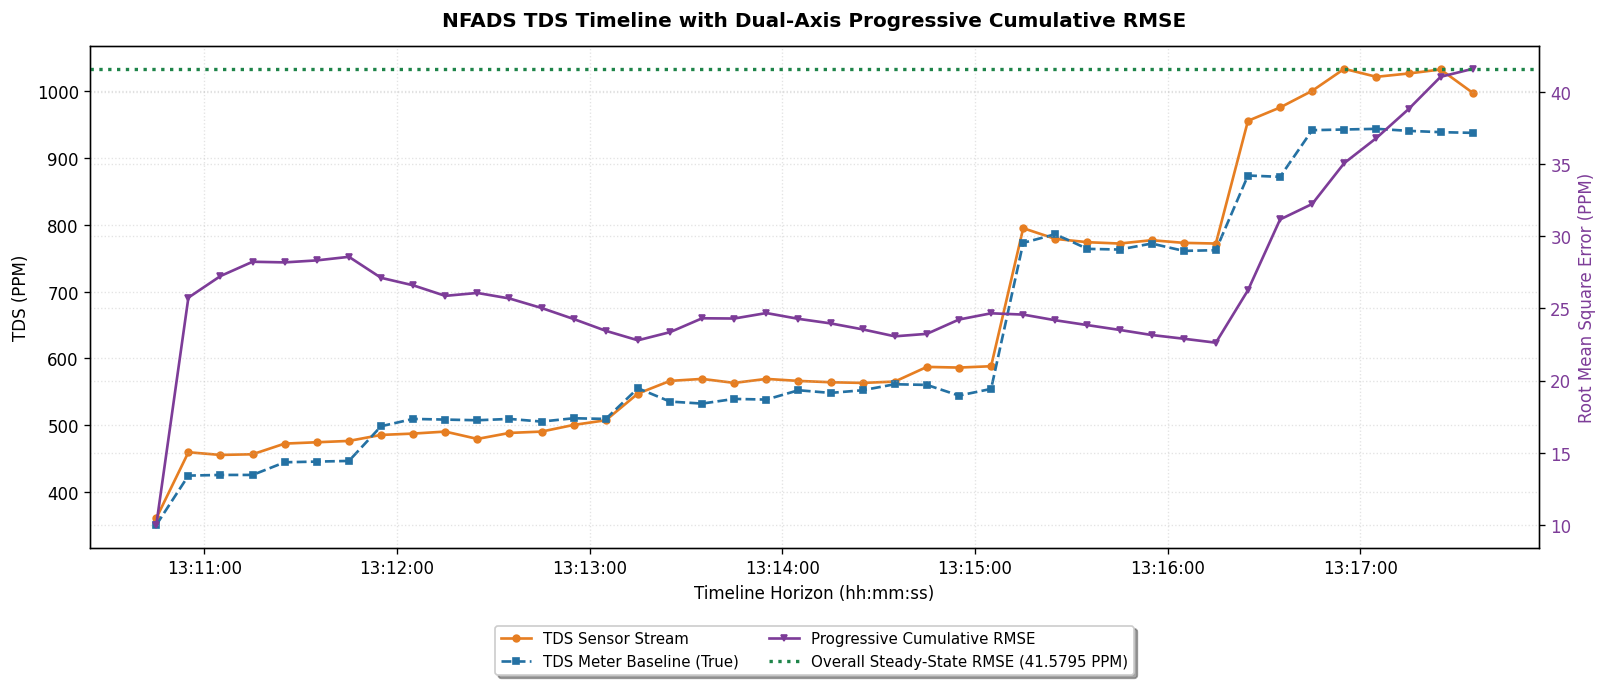

NFADS Nutrient Temperature Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_water_temp.png


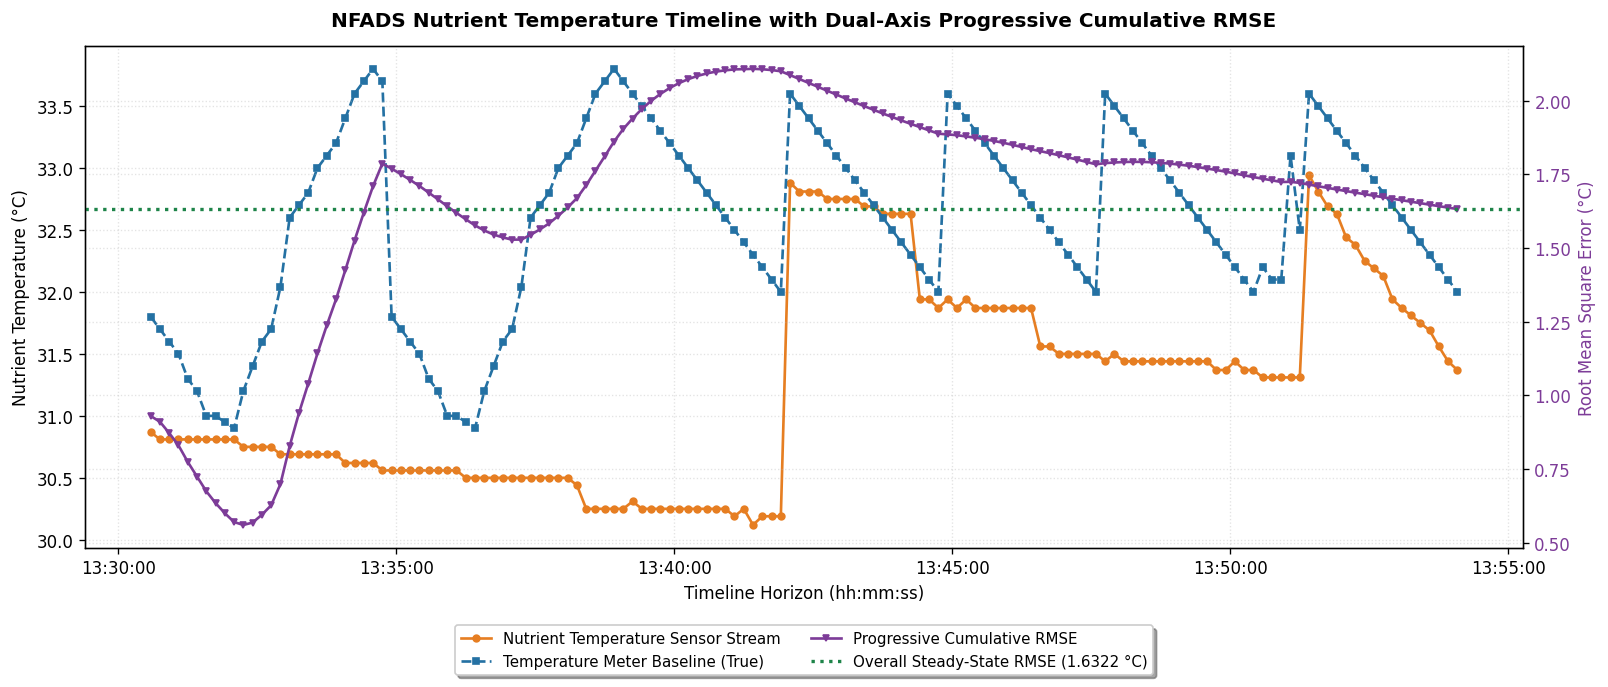

Unified EMS Climate Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_ems_temp.png


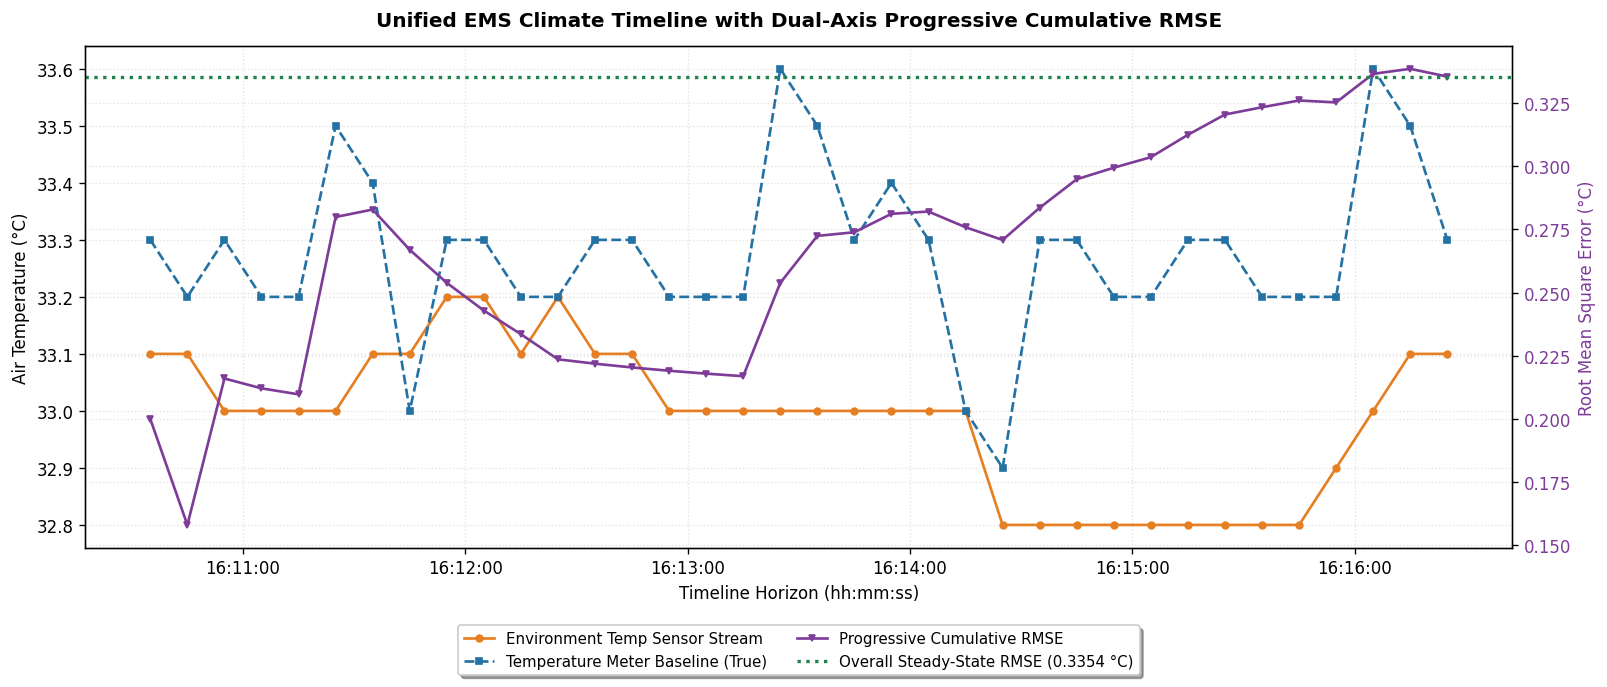

LMS Light Intensity Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_lux.png


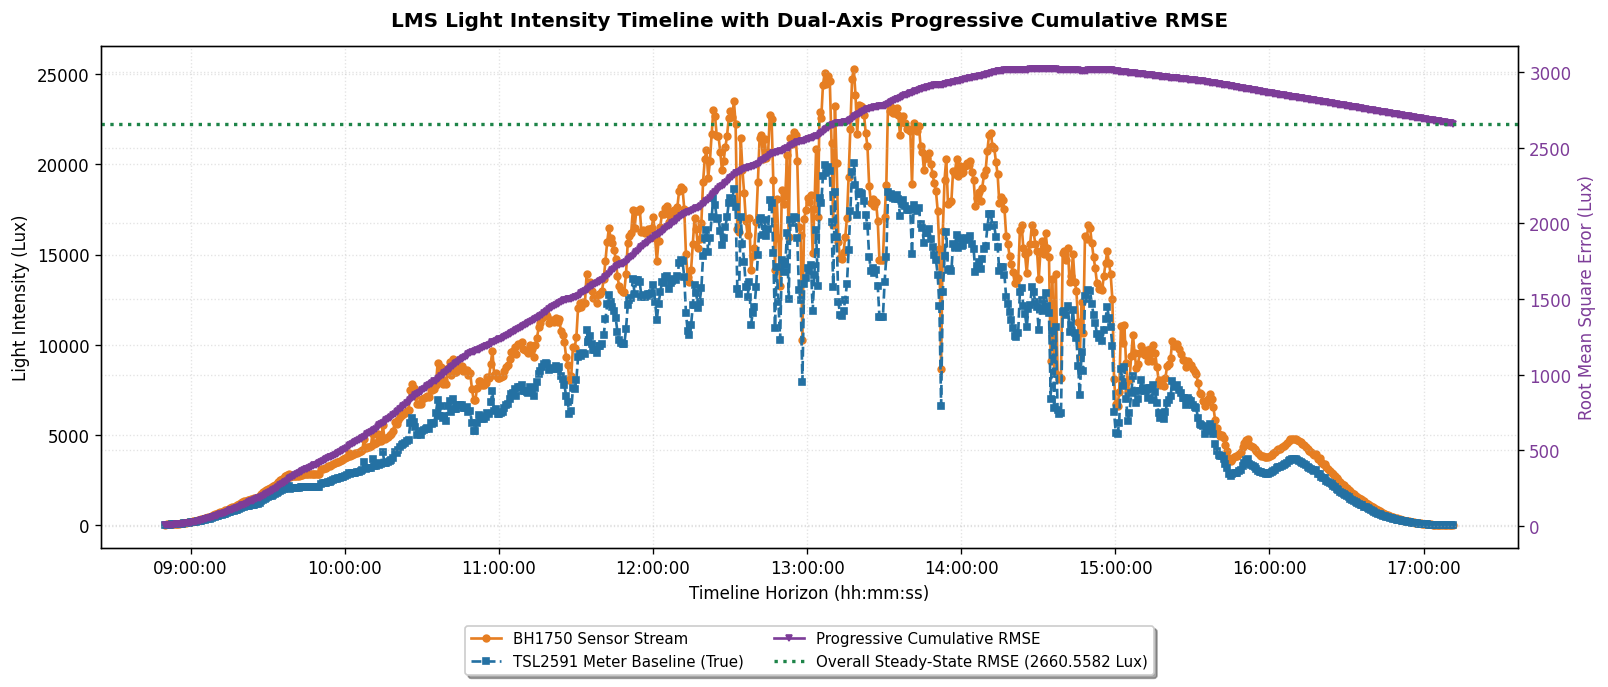

,dataset,y_axis,n_points,steady_state_rmse,rmse_unit
0,tds,TDS (PPM),42,41.579528,PPM
1,water_temp,Nutrient Temperature (°C),142,1.632215,°C
2,ems_temp,Air Temperature (°C),36,0.335410,°C
3,lux,Light Intensity (Lux),753,2660.558224,Lux


In [8]:
summary_rows = []
for cfg in PLOT_CONFIGS:
    print('=' * 72)
    print(cfg['title'])
    stats = plot_dual_axis_timeline(datasets[cfg['key']], cfg)
    summary_rows.append({
        'dataset': cfg['key'],
        'y_axis': cfg['y_label'],
        'n_points': stats['n'],
        'steady_state_rmse': stats['steady_rmse'],
        'rmse_unit': cfg['rmse_unit'],
    })

summary = pd.DataFrame(summary_rows)
try:
    from IPython.display import display
    display(summary)
except ImportError:
    print(summary.to_string(index=False))